# Klassificering av ansiktsuttryck med deep learning

Detta projekt går ut på att bygga en modell med neurala nätverk som kan klassificera ansiktsutryck. 

Projektet inleds med en undersökning av datan och förberedelse av den. Då datasetet är stort så används initialt ett subset.

En basmodel byggs och olika experiment för att undersöka om den kan förbättras genomförs.

Den modell som får högst accuracy på valideringsdatan, är någorlunda stabil och snabb väljs för att tränas på hela träningsdatan.

En bredare och en djupare modellvariant undersöks också i samband med att hela träningsdatan används då bredare och djupare modeller kan fungera bättre med större mängd data.

In [1]:
# Grundläggande bibliotek
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Train/validation-split och utvärdering
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping

tf.keras.utils.set_random_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 1. Förstå datan

Datasetet som används är FER-2013 och är redan uppdelat i ett träningsset och ett testset. Träningssetet används för att lära modellen klassificera ansiktsutryck medan testsetet endats används på slutat för att utvärdera modellen.

In [2]:
# Titta på datan

import os

# Räknar antal bilder totalt och per klass i tränings- och testdata

print("Antal klasser i train:", len(os.listdir("data/train")))
total_train_images = 0
for class_name in sorted(os.listdir("data/train")):
    count = len(os.listdir(f"data/train/{class_name}"))
    total_train_images += count
    print(f"{class_name}: {count} bilder")
print(f"\nTotalt antal bilder i train: {total_train_images}")

print("---------------------------------------------")

print(f"Antal klasser i test:", len(os.listdir("data/test")))
total_test_images = 0
for class_name in sorted(os.listdir("data/test")):
    count = len(os.listdir(f"data/test/{class_name}"))
    total_test_images += count
    print(f"{class_name}: {count} bilder")
print(f"\nTotalt antal bilder i test: {total_test_images}")

Antal klasser i train: 7
angry: 3995 bilder
disgust: 436 bilder
fear: 4097 bilder
happy: 7215 bilder
neutral: 4965 bilder
sad: 4830 bilder
surprise: 3171 bilder

Totalt antal bilder i train: 28709
---------------------------------------------
Antal klasser i test: 7
angry: 958 bilder
disgust: 111 bilder
fear: 1024 bilder
happy: 1774 bilder
neutral: 1233 bilder
sad: 1247 bilder
surprise: 831 bilder

Totalt antal bilder i test: 7178


### Kommentar:  
Träningsdatan består av 28709 bilder och tesdatan av 7178 bilder vilket är 20% av det totala antalet bilder 35887.  
Klassen disgust sticker ut med färre bilder 436, runt 10 procent av övriga. Störst är klassen happy med 7215 bilder som är dubbelt så stor som den nästa minsta klassen surprise med 3171 bilder.

## 2. Förbered datan

In [3]:
# Packar upp zip-filen

import zipfile

with zipfile.ZipFile("data/FER-2013.zip", "r") as zip_ref:
    zip_ref.extractall("data/")

### Läser in data  

Datan läses in med ImageDataGenerator och normaliseras genom att pixelvärdena skalas från 0-255 till 0-1. Med flow_from_directory skalas bilderna till 48x48 pixlar och en kanal för gråskala. Labels sätts till heltal (sparse). För att underlätta vidare arbete så konverteras datan till numpy arrays.

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = "data/train"
test_dir = "data/test"

# Normaliserar pixelvärden från 0-255 till 0-1
datagen = ImageDataGenerator(rescale=1./255)

# Läser in bilder från mappstruktur, 48x48 gråskala, labels som heltal
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode="grayscale",
    class_mode="sparse",
    batch_size=32,
    shuffle=False
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(48, 48),
    color_mode="grayscale",
    class_mode="sparse",
    batch_size=32,
    shuffle=False
)

# Konvertera till numpy-arrays
X_train_full = np.concatenate([train_generator[i][0] for i in range(len(train_generator))], axis=0)
y_train_full = np.concatenate([train_generator[i][1] for i in range(len(train_generator))], axis=0).astype(int)

X_test = np.concatenate([test_generator[i][0] for i in range(len(test_generator))], axis=0)
y_test = np.concatenate([test_generator[i][1] for i in range(len(test_generator))], axis=0).astype(int)

# Sätter klassnamn baserat på mappstruktur
class_names = list(train_generator.class_indices.keys())

print("X_train_full:", X_train_full.shape)
print("y_train_full:", y_train_full.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print(f"\nLabels på klasserna:")
for i, name in enumerate(class_names):
    print(i, name)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
X_train_full: (28709, 48, 48, 1)
y_train_full: (28709,)
X_test: (7178, 48, 48, 1)
y_test: (7178,)

Labels på klasserna:
0 angry
1 disgust
2 fear
3 happy
4 neutral
5 sad
6 surprise


### Exempelbilder

För att förstå datan bättre skrivs ett slumpmässigt antal bilder med klassnamn ut.

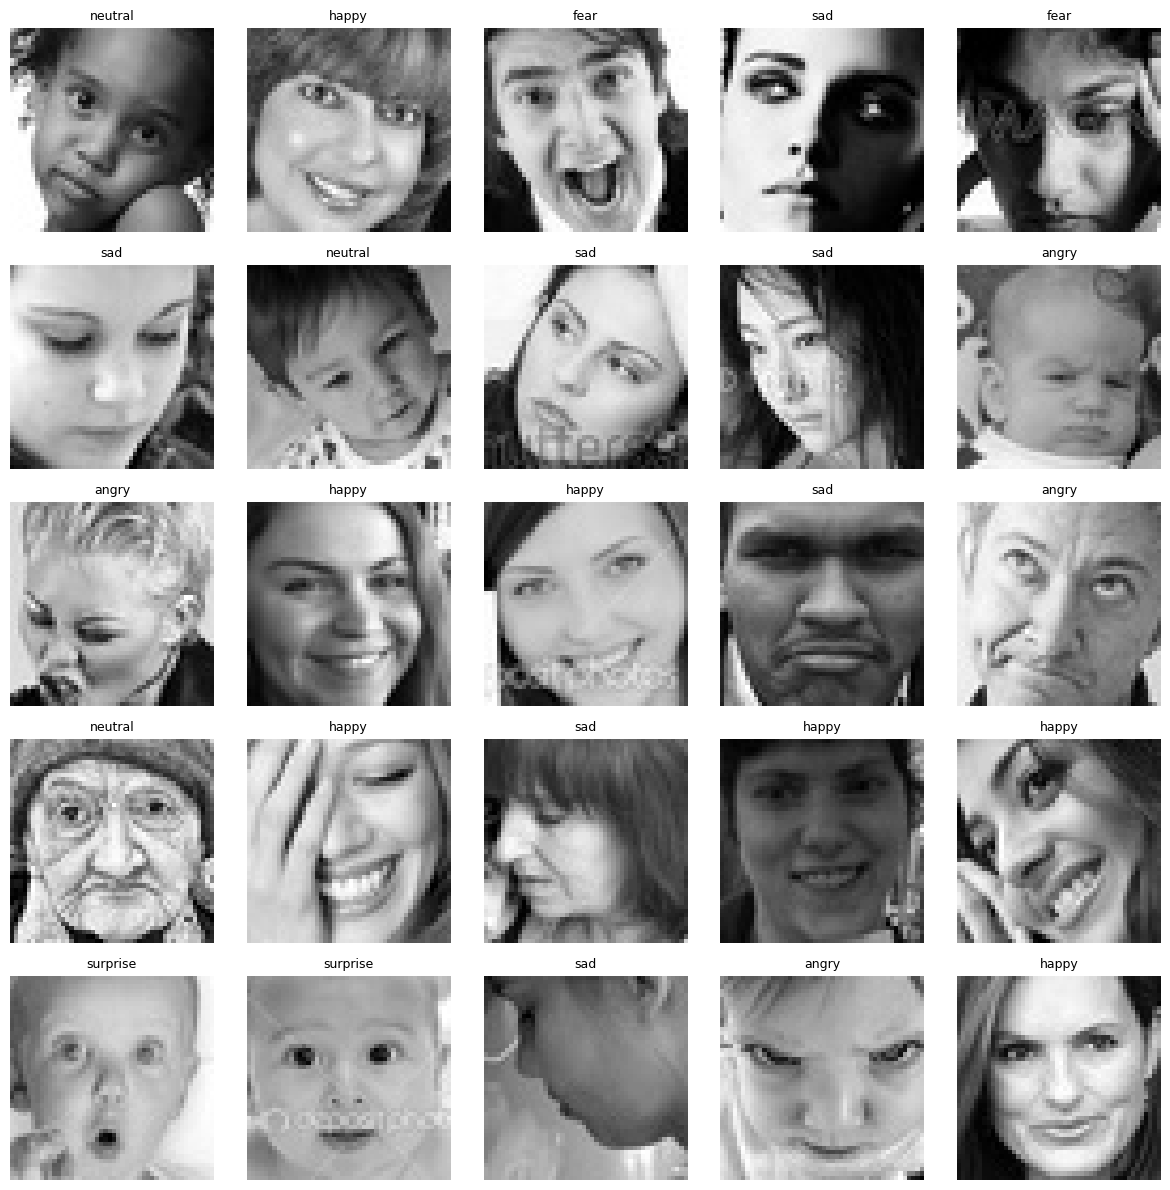

In [5]:
# Skriver ut 25 slumpmässiga bilder från träningsdata med deras klassnamn

n_images = 25
rng = np.random.default_rng(seed=42)
indices = rng.choice(len(X_train_full), size=n_images, replace=False)
plt.figure(figsize=(12, 12))

for i in range(n_images):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train_full[indices[i]].squeeze(), cmap="gray")
    plt.title(class_names[y_train_full[indices[i]]], fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Kommentar

Av de 25 slumpmässigt utvalda bilderna syns ingen disgust, vilket speglar klassens underrepresentation i datasetet.  

(Vissa av bilderna skulle jag ha tolkat som andra ansiktsuttryck vilket indikerar att denna typ av klassificering är antingen subjektiv eller att en del bilder är felklassificerade, eller båda.)

### Ta bort klassen disgust

Då klassen "disgust" innehåll betydligt färre bilder än övriga klasser så kommer klassen tas bort just nu för att få en mer robust modell. Om mer data 
samlas in i framtiden kan modellen tränas om med klassen inkluderad. 

In [6]:
# Ta bort disgust (klass 1) i träningsdata
mask = y_train_full != 1
X_filtered = X_train_full[mask]
y_filtered = y_train_full[mask]

# Ta bort disgust från testdata
mask_test = y_test != 1
X_test_filtered = X_test[mask_test]
y_test_filtered = y_test[mask_test]

# Mappa om labels till 0-5
unique_labels = np.unique(y_filtered)
label_map = {old: new for new, old in enumerate(unique_labels)}
y_filtered = np.array([label_map[y] for y in y_filtered])
y_test_filtered = np.array([label_map[y] for y in y_test_filtered])

# Uppdatera klassnamn utan disgust
class_names_filtered = [name for name in class_names if name != "disgust"]

### Skapa subset

Träningssetet innehåller 28709 bilder vilket kan ta lång tid att träna på. Experimenten kommer därför utföras på ett balanserat subset där alla klasser får lika stor storlek, vilket ger modellen lika goda förutsättningar att lära sig känna igen varje klass. När en optimal modell hittats kan träning ske på hela träningsdatan.

In [7]:
# Skapar ett balanserat subset med 500 bilder per klass
samples_per_class=500
rng = np.random.default_rng(42)
selected_indices = []

for class_id in np.unique(y_filtered):
    class_indices = np.where(y_filtered == class_id)[0]   
    chosen_indices = rng.choice(class_indices, size=samples_per_class, replace=False)
    selected_indices.extend(chosen_indices)

selected_indices = np.array(selected_indices)
rng.shuffle(selected_indices)

X_subset = X_filtered[selected_indices]
y_subset = y_filtered[selected_indices]

# Utskrift för kontroll av shapes och klassfördelning i det nya subsetet
print("X_subset:", X_subset.shape)
print("y_subset:", y_subset.shape)
print("\nLabels på klasserna efter borttagning av disgust och subset:")
unique, counts = np.unique(y_subset, return_counts=True)
for label, count in zip(unique, counts):
    print(f"{label} {class_names_filtered[label]}: {count} bilder")

X_subset: (3000, 48, 48, 1)
y_subset: (3000,)

Labels på klasserna efter borttagning av disgust och subset:
0 angry: 500 bilder
1 fear: 500 bilder
2 happy: 500 bilder
3 neutral: 500 bilder
4 sad: 500 bilder
5 surprise: 500 bilder


### Skapa valideringsset

Ett valideringsdataset skapas av 20% av träningsdatan för att kunna utvärdera hur modellen presterar på data den inte tränats på. Under träningen 
används valideringsdatan för att upptäcka om modellen lär sig träningsdatan för bra och överanpassar.

Eftersom subsettet redan är balanserat är stratifiering inte nödvändigt men används ändå som en säkerhetsåtgärd.

In [8]:
# Skapa validationsset från det nya subsetet (20% av datan)
X_train, X_val, y_train, y_val = train_test_split(
    X_subset,
    y_subset,
    test_size=0.20,
    random_state=42,
    stratify=y_subset
)

# Utskrift för kontroll av shapes i train/val-split
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (2400, 48, 48, 1)
X_val: (600, 48, 48, 1)
y_train: (2400,)
y_val: (600,)


## 3 och 4. Bygg en modell, träna modellen

### Funktion för att bygga och compilera modeller

Modellen är ett CNN (Convolutional Neural Network) med två eller en variant med tre Conv2D-lager som extraherar visuella mönster från bilderna, följt av MaxPooling-lager som reducerar bildernas storlek. Därefter plattas datan ut med ett Flatten-lager och skickas vidare till ett fully connected lager (Dense) som lär sig kombinera mönstren för klassificering. Sista lagret har 6 noder med softmax-aktivering, ett per känslouttryck, som ger sannolikheten för varje klass. Dropout och L2-regularisering kan läggas till för att motverka överanpassning.

Grundinställningar: 32 och 64 filter i de två första Conv2D-lagren, kernelstorlek 3×3, 128 noder i det fully connected lagret och learning rate 0.001 med Adam som optimerare. Dessa värden justeras i de följande experimenten.

In [9]:
def build_model(
        num_filters_1=32,
        num_filters_2=64,
        num_filters_3=None,
        kernel_size=(3, 3),
        dense_units=128,
        learning_rate=0.001,
        dropout_rate=0.0,
        l2_strength=0.0
):
    """
    Bygger och kompilerar en CNN med två eller tre Conv2D-lager följt av ett fully connected lager (dense).
    Stöder dropout och L2-regularisering som hyperparametrar.

    Returnerar: kompilerad Keras-modell
    """
    tf.keras.utils.set_random_seed(42)
    
    kernels_regularizer = (
        regularizers.l2(l2_strength)
        if l2_strength > 0
        else None
    )

    model = keras.Sequential([
        layers.Input(shape=(48, 48, 1)),

        layers.Conv2D(num_filters_1, kernel_size=kernel_size, activation="relu",
                      padding="same", kernel_regularizer=kernels_regularizer),

        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(num_filters_2, kernel_size=kernel_size, activation="relu",
                      padding="same", kernel_regularizer=kernels_regularizer),
                      
        layers.MaxPooling2D(pool_size=(2, 2)),
    ])

    # Valfritt tredje Conv2D-lager
    if num_filters_3:
        model.add(layers.Conv2D(num_filters_3, kernel_size=kernel_size, activation="relu",
                                padding="same", kernel_regularizer=kernels_regularizer))
        
        model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    model.add(layers.Flatten())

    model.add(layers.Dense(dense_units, activation="relu",
                            kernel_regularizer=kernels_regularizer))
        
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(6, activation="softmax"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

### Funktion för att skapa träningskurvor

Träningskurvorna visar hur modellens loss och accuracy utvecklas över epoker för både tränings- och valideringsdata. Kurvorna används för att bedöma om 
modellen lär sig och om det finns tecken på överanpassning.

In [10]:
def plot_history(history, title="Träningskurvor"):

    """
    Plottar tränings- och valideringsförlust samt accuracy över epoker.
    """

    # Konverterar Keras History-objekt till DataFrame för enklare plottning    
    history_df = pd.DataFrame(history.history)

    epochs = range(1, len(history_df) + 1)

    plt.figure(figsize=(12, 4))

    # Plottar loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_df["loss"], label="Traning loss")
    plt.plot(epochs, history_df["val_loss"], label="Validation loss")
    plt.xlabel("Epok")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    # Plottar accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_df["accuracy"], label="Traning accuracy")
    plt.plot(epochs, history_df["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epok")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

### Funktion för att köra experiment och träna modeller

Experimenten körs med funktionen run_experiment som bygger och tränar en modell med angivna hyperparametrar. Resultaten sparas i en lista för att enkelt kunna jämföras mellan experiment. Alla mått hämtas från den epok som gav bäst valideringsnoggrannhet, vilket inte alltid behöver vara den sista.

In [ ]:
def run_experiment(
        name,
        epochs=15,
        learning_rate=0.001,
        batch_size=64,
        num_filters_1=32,
        num_filters_2=64,
        num_filters_3=None,
        kernel_size=(3, 3),
        dense_units=128,
        dropout_rate=0.0,
        l2_strength=0.0,
        callbacks=None,
        verbose=0
):
    
    """
    Bygger, tränar och utvärderar en modell med angivna hyperparametrar.
    Returnerar: modell, history och dict med resultatmått.
    """

    model = build_model(
        num_filters_1=num_filters_1,
        num_filters_2=num_filters_2,
        num_filters_3=num_filters_3,
        kernel_size=kernel_size,
        dense_units=dense_units,
        learning_rate=learning_rate,
        dropout_rate=dropout_rate,
        l2_strength=l2_strength
    )

    print(f"\nExperiment: {name}")
    start_time = time.time()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose
    )

    training_time = time.time() - start_time

    # Hämtar resultat från bästa epok baserat på val_accuracy
    best_index = np.argmax(history.history["val_accuracy"])

    train_acc  = history.history["accuracy"][best_index]
    train_loss = history.history["loss"][best_index]
    val_acc  = history.history["val_accuracy"][best_index]
    val_loss = history.history["val_loss"][best_index]


    print(f"Antal epoker: {len(history.history['loss'])}")
    print(f"Training accuracy: {train_acc:.4f}")
    print(f"Training loss: {train_loss:.4f}")
    print(f"Validation accuracy: {val_acc:.4f}")
    print(f"Validation loss: {val_loss:.4f}")
    print(f"Träningstid: {training_time:.2f} sekunder")

    plot_history(history, title=name)

    return model, history, {
        "name": name,
        "train_accuracy": train_acc,
        "train_loss": train_loss,
        "val_accuracy": val_acc,
        "val_loss": val_loss,
        # "epochs_trained": len(history.history["loss"]),
        "best_epoch": best_index + 1,
        "training_time": training_time
    }

### Experiment

Experimenten utgår från en basmodell och förändringar görs iterativt utifrån resultaten.


Experiment: Basmodell
Antal epoker:   15
Training accuracy:      0.7237
Training loss:          0.7944
Validation accuracy: 0.3933
Validation loss:     1.9146
Träningstid:    22.39 sekunder


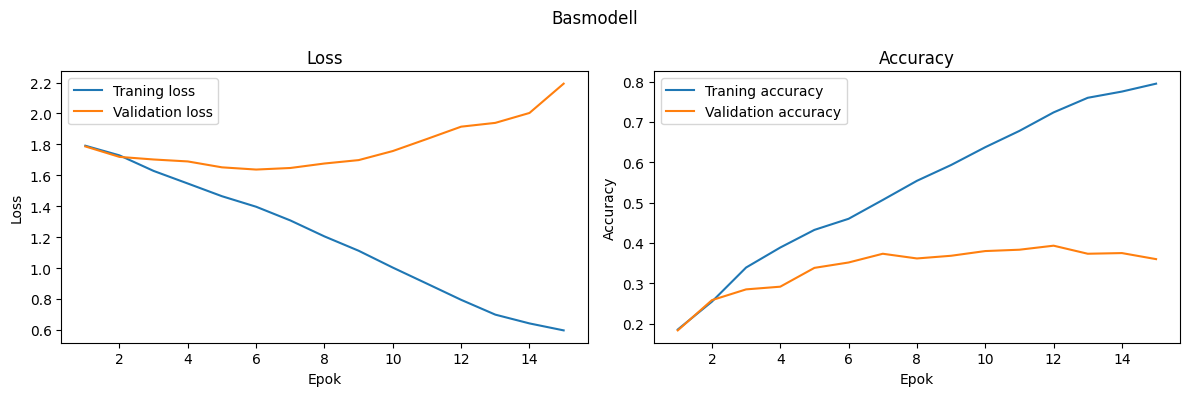

     name  train_accuracy  train_loss  val_accuracy  val_loss  best_epoch  training_time
Basmodell         0.72375    0.794418      0.393333  1.914599          12      22.387358


In [12]:
# Basmodell

results = []

_, h_bas, r_bas = run_experiment("Basmodell")

results.append(r_bas)

print(pd.DataFrame(results).to_string(index=False))

### Kommentar

Basmodellen börjar överanpassa efter cirka 6 epoker accuracy på träningsdatan fortsätter öka medan accuracy på valideringsdatan planar ut. Efter 15 epoker når accuracy på träningsdatan 0,79 men på valideringsdatan bara 0,39. 
 
Ett nästa steg är att prova olika dropout-nivåer där en del av neuronerna stängs av slumpmässigt under träning för att motverka överanpassningen.


Experiment: Dropout 0.2
Antal epoker:   15
Training accuracy:      0.7788
Training loss:          0.6184
Validation accuracy: 0.3750
Validation loss:     2.0913
Träningstid:    22.64 sekunder


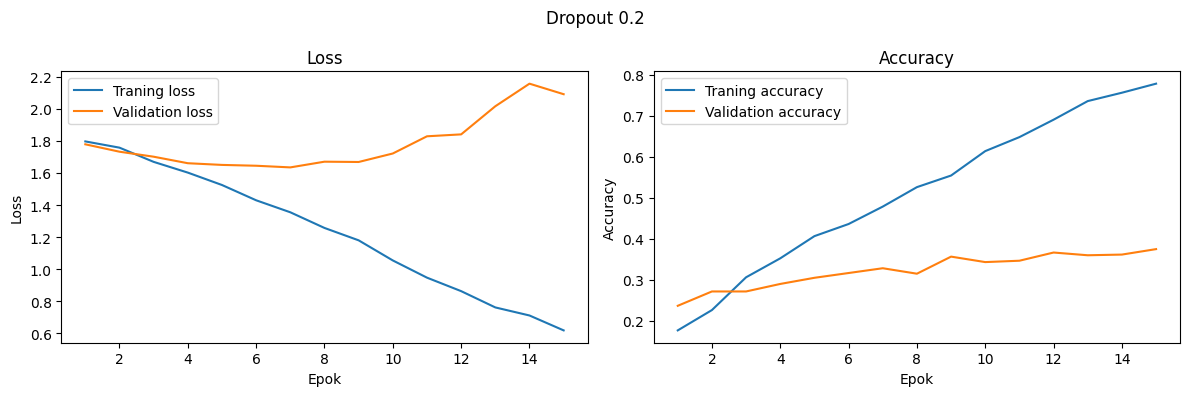


Experiment: Dropout 0.4
Antal epoker:   15
Training accuracy:      0.5992
Training loss:          1.0467
Validation accuracy: 0.3817
Validation loss:     1.6984
Träningstid:    22.52 sekunder


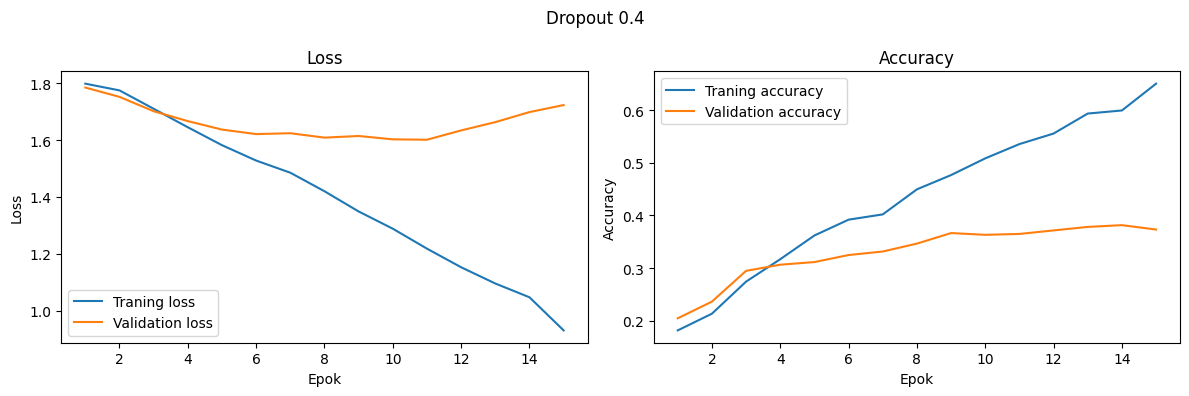


Experiment: Dropout 0.5
Antal epoker:   15
Training accuracy:      0.6025
Training loss:          1.0584
Validation accuracy: 0.3700
Validation loss:     1.7027
Träningstid:    22.41 sekunder


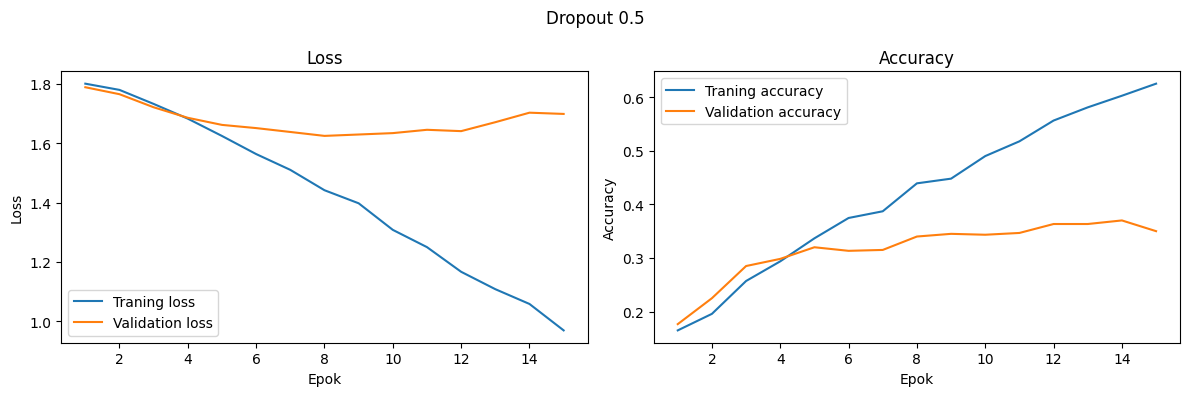

       name  train_accuracy  train_loss  val_accuracy  val_loss  best_epoch  training_time
  Basmodell        0.723750    0.794418      0.393333  1.914599          12      22.387358
Dropout 0.2        0.778750    0.618427      0.375000  2.091327          15      22.640146
Dropout 0.4        0.599167    1.046693      0.381667  1.698354          14      22.519528
Dropout 0.5        0.602500    1.058368      0.370000  1.702722          14      22.411260


In [13]:
# Experiment med olika dropout

_, h_drop1, r_drop1 = run_experiment("Dropout 0.2", dropout_rate=0.2)
_, h_drop2, r_drop2 = run_experiment("Dropout 0.4", dropout_rate=0.4)
_, h_drop3, r_drop3 = run_experiment("Dropout 0.5", dropout_rate=0.5)

results.extend([r_drop1, r_drop2, r_drop3])
print(pd.DataFrame(results).to_string(index=False))

### Kommentar

Dropout minskade gapet mellan accuracy på träningsdatan och valideringsdatan, dvs överanpassningen minskade men accuracy på valideringsdatan blev sämre än för basbodellen. Det tyder på att modellen får svårare att lära sig med mer begränsad data.

I nästa experiment testas olika l2-styrkor för att reducera överanpassningen. L2 straffar modellen om den har för stora vikter och tvingar den generalisera bättre.


Experiment: L2 0.01
Antal epoker:   15
Training accuracy:      0.3262
Training loss:          1.7051
Validation accuracy: 0.3050
Validation loss:     1.7410
Träningstid:    24.84 sekunder


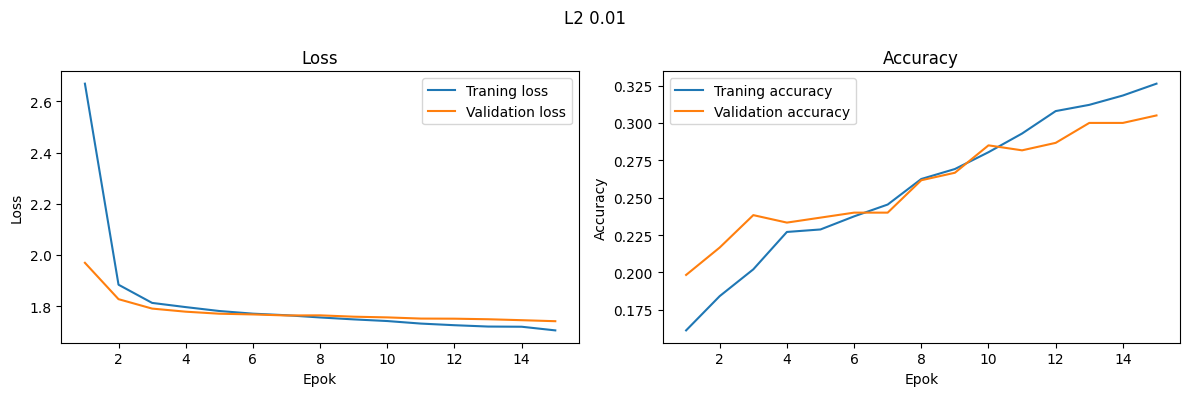


Experiment: L2 0.001
Antal epoker:   15
Training accuracy:      0.6171
Training loss:          1.1525
Validation accuracy: 0.3933
Validation loss:     1.8723
Träningstid:    24.03 sekunder


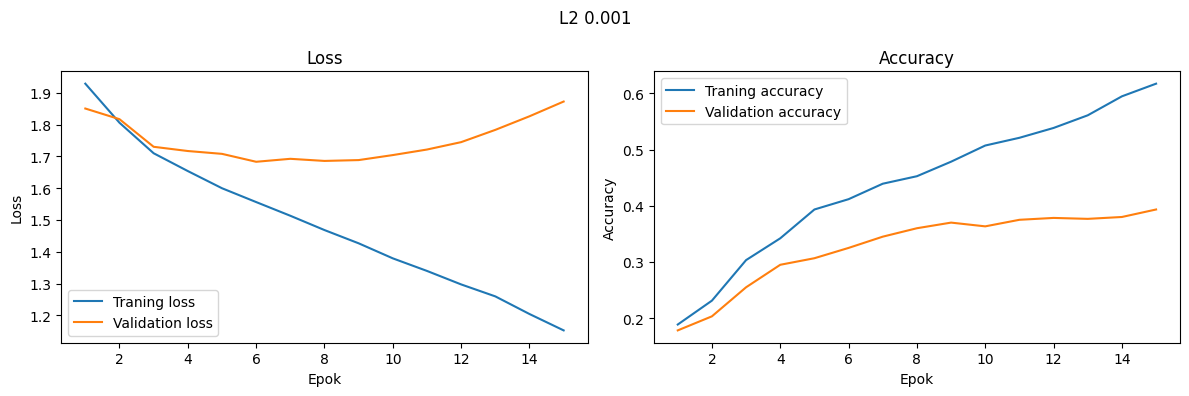


Experiment: L2 0.0001
Antal epoker:   15
Training accuracy:      0.5767
Training loss:          1.1725
Validation accuracy: 0.3833
Validation loss:     1.6977
Träningstid:    24.00 sekunder


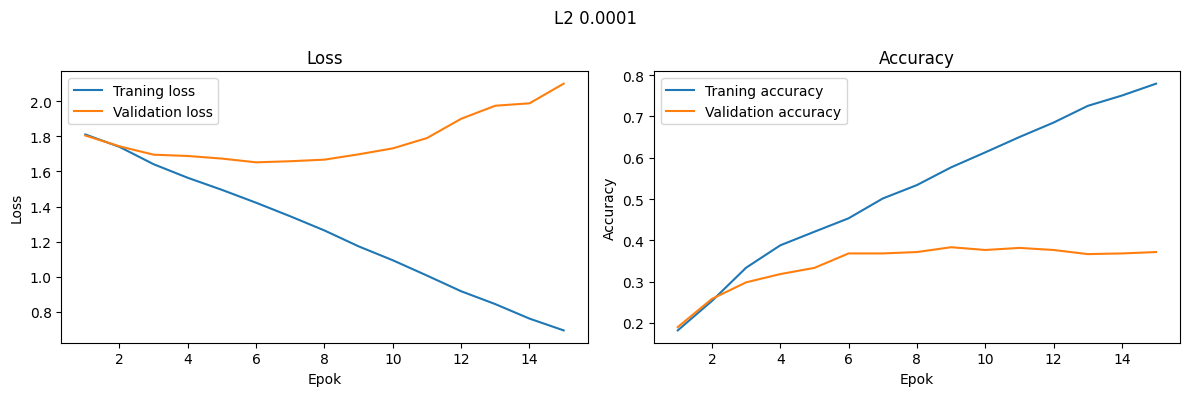

       name  train_accuracy  train_loss  val_accuracy  val_loss  best_epoch  training_time
  Basmodell        0.723750    0.794418      0.393333  1.914599          12      22.387358
Dropout 0.2        0.778750    0.618427      0.375000  2.091327          15      22.640146
Dropout 0.4        0.599167    1.046693      0.381667  1.698354          14      22.519528
Dropout 0.5        0.602500    1.058368      0.370000  1.702722          14      22.411260
    L2 0.01        0.326250    1.705103      0.305000  1.740972          15      24.838328
   L2 0.001        0.617083    1.152550      0.393333  1.872329          15      24.034297
  L2 0.0001        0.576667    1.172518      0.383333  1.697725           9      24.002508


In [14]:
# Experiment med olika L2-styrkor

_, h_l2_1, r_l2_1 = run_experiment("L2 0.01", l2_strength=0.01)
_, h_l2_2, r_l2_2 = run_experiment("L2 0.001", l2_strength=0.001)
_, h_l2_3, r_l2_3 = run_experiment("L2 0.0001", l2_strength=0.0001)

results.extend([r_l2_1, r_l2_2, r_l2_3])
print(pd.DataFrame(results).to_string(index=False))

### Kommentar

L2-regularisering gav ingen förbättring utan basmodellen har forfarande högst accuracy på valideringsdatan. L2 0,01 var för stark och hämmade inlärningen kraftigt och uppnådde bara 30,5% accuracy på valideringsdatan medan L2 0,001 och 0,0001 gav liknande resultat som basmodellen. 
Kurvorna visar att träning och validering följer varandra bättre med L2, men på bekostnad av lägre total accuracy.

Att testa early stopping bedöms inte meningsfullt då överanpassning sker inom 6-8 epoker. Nästa experiment görs med olika learning rates.


Experiment: LR 0.0001
Antal epoker:   15
Training accuracy:      0.4683
Training loss:          1.3876
Validation accuracy: 0.3600
Validation loss:     1.6079
Träningstid:    22.70 sekunder


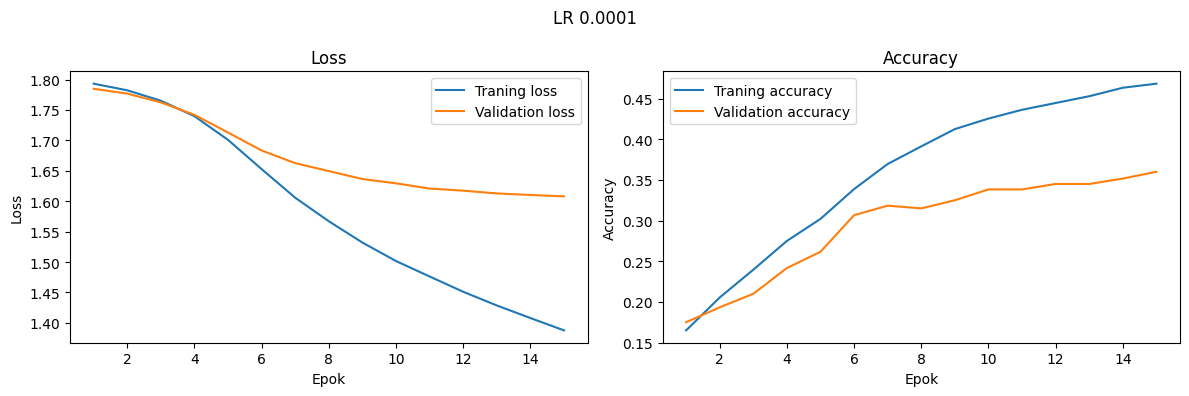


Experiment: LR 0.0005
Antal epoker:   15
Training accuracy:      0.6750
Training loss:          0.9397
Validation accuracy: 0.4067
Validation loss:     1.7011
Träningstid:    24.14 sekunder


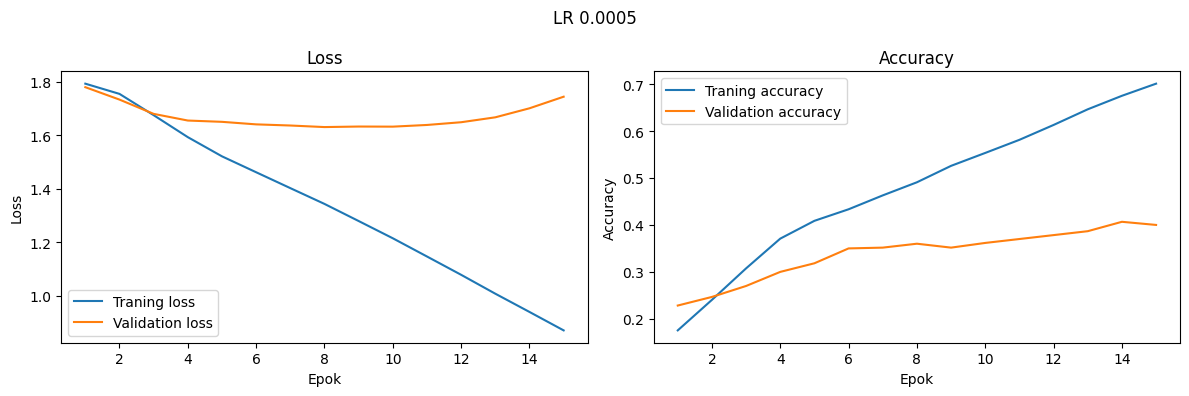


Experiment: LR 0.01
Antal epoker:   15
Training accuracy:      0.5625
Training loss:          1.1797
Validation accuracy: 0.3183
Validation loss:     1.9484
Träningstid:    23.34 sekunder


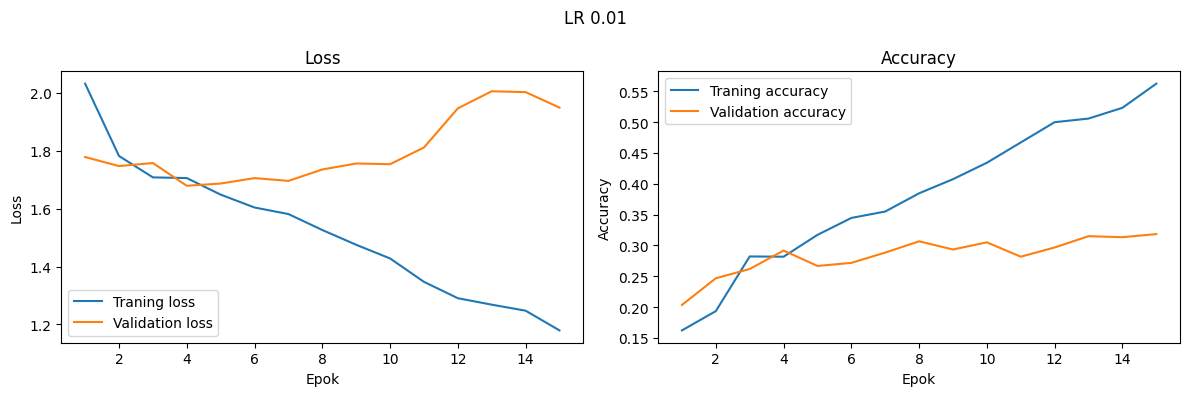

       name  train_accuracy  train_loss  val_accuracy  val_loss  best_epoch  training_time
  Basmodell        0.723750    0.794418      0.393333  1.914599          12      22.387358
Dropout 0.2        0.778750    0.618427      0.375000  2.091327          15      22.640146
Dropout 0.4        0.599167    1.046693      0.381667  1.698354          14      22.519528
Dropout 0.5        0.602500    1.058368      0.370000  1.702722          14      22.411260
    L2 0.01        0.326250    1.705103      0.305000  1.740972          15      24.838328
   L2 0.001        0.617083    1.152550      0.393333  1.872329          15      24.034297
  L2 0.0001        0.576667    1.172518      0.383333  1.697725           9      24.002508
  LR 0.0001        0.468333    1.387568      0.360000  1.607910          15      22.702733
  LR 0.0005        0.675000    0.939655      0.406667  1.701102          14      24.138924
    LR 0.01        0.562500    1.179667      0.318333  1.948357          15      23.339656

In [15]:
# Experiment med olika learning rates

_, h_lr1, r_lr1 = run_experiment("LR 0.0001", learning_rate=0.0001)
_, h_lr2, r_lr2 = run_experiment("LR 0.0005", learning_rate=0.0005)
_, h_lr3, r_lr3 = run_experiment("LR 0.01", learning_rate=0.01)

results.extend([r_lr1, r_lr2, r_lr3])
print(pd.DataFrame(results).to_string(index=False))

### Kommentar

Av de testade learning rates gav LR 0,0005 den hittils bästa accuracy på valideringsdatan, 40,7% vilket är en lite förbättring mot basmodellens 39,3%. LR 0,0001 lärde sig långsamt medan LR 0,01 blev instabil med ojämna kurvor. 

I nästa experiment testas en bredare modell för att se om den kan bli bättre på att lära sig de komplexa mönster som ansiktsuttryck är. Antalet filter i Conv2D-lagren dubblas till 64 och 128, och även fully connected lagret dubbleras till 256 noder.  
Fler filter gör att modellen kan detektera fler olika mönster på samma nivå medan fler noder kan lagra fler kombinationer av mönster. 
En risk med en bredare model på en liten datamängd är att den överanpassar mer.


Experiment: Större modell
Antal epoker:   15
Training accuracy:      0.7400
Training loss:          0.7393
Validation accuracy: 0.3917
Validation loss:     2.1762
Träningstid:    60.43 sekunder


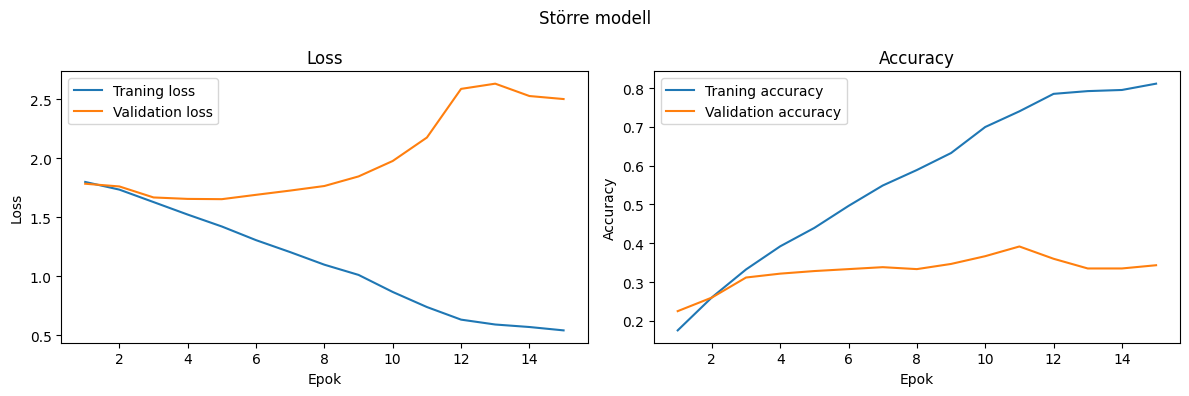

         name  train_accuracy  train_loss  val_accuracy  val_loss  best_epoch  training_time
    Basmodell        0.723750    0.794418      0.393333  1.914599          12      22.387358
  Dropout 0.2        0.778750    0.618427      0.375000  2.091327          15      22.640146
  Dropout 0.4        0.599167    1.046693      0.381667  1.698354          14      22.519528
  Dropout 0.5        0.602500    1.058368      0.370000  1.702722          14      22.411260
      L2 0.01        0.326250    1.705103      0.305000  1.740972          15      24.838328
     L2 0.001        0.617083    1.152550      0.393333  1.872329          15      24.034297
    L2 0.0001        0.576667    1.172518      0.383333  1.697725           9      24.002508
    LR 0.0001        0.468333    1.387568      0.360000  1.607910          15      22.702733
    LR 0.0005        0.675000    0.939655      0.406667  1.701102          14      24.138924
      LR 0.01        0.562500    1.179667      0.318333  1.948357     

In [ ]:
# Experiment med bredare modell

_, h_big, r_big = run_experiment(
    "Bredare modell",
    num_filters_1=64,
    num_filters_2=128,
    dense_units=256,
)

results.append(r_big)
print(pd.DataFrame(results).to_string(index=False))

### Kommentar

Den bredare modellen överanpassar mycket och loss på valideringsdatan är det högsta av alla experiment hittils. Modellen har ett något lägre accuracy på valideringsdatan än basmodellen trota att den tränat tre gånger så länge, ca 60 sekunder mot övriga som ligger strax över 20 sekunder. Detta är ett tecken på att med begränsad data så lär sig en bredare modell träningsdatan bättre iställer för att generalisera.

Nästa steg är att ta basmodellen med leaning rate 0,0005 och använda hela träningsdatan för att se om mer data förbättrar generaliseringen.

### Träna modellen på hela träningsdatan

Modellen som väljs är basmodellen med learning rate 0,0005.

För att se om den bredare modellen presterar bättre med mer data så tränas även den på hela träningsdatan.

Med mer data blir det också intressant att testa en modell med ett tredje Conv2D-lager. Varje Conv2D-lager bygger på det föregående. Tidiga lager hittar enkla mönster (kanter, linjer), senare lager kombinerar dessa till mer abstrakta mönster (ögon, munnar). 

In [17]:
# Skapa tränings- och valideringsuppsättningar med alla bilder (utan disgust)
X_train_full, X_val_full, y_train_full, y_val_full = train_test_split(
    X_filtered,
    y_filtered,
    test_size=0.20,
    random_state=42,
    stratify=y_filtered
)

# Utskrift för kontroll av shapes i train/val-split
print("X_train:", X_train_full.shape)
print("X_val:", X_val_full.shape)
print("y_train:", y_train_full.shape)
print("y_val:", y_val_full.shape)

X_train: (22618, 48, 48, 1)
X_val: (5655, 48, 48, 1)
y_train: (22618,)
y_val: (5655,)


#### Funktion för att jämföra modeller som körts på subset och hela träningsdatan

In [18]:
# Jämför en modells resultat på subset vs full träningsdata
def compare_subset_vs_full(name_subset, r_subset, name_full, r_full):
    """
    Skapar en DataFrame för att jämföra resultat mellan en modell tränad på subset vs samma modell tränad på hela datan.
    """
    df = pd.DataFrame([
        {"Modell": name_subset,
         "Training Accuracy": r_subset["train_accuracy"],
         "Training Loss": r_subset["train_loss"],
         "Validation Accuracy": r_subset["val_accuracy"],
         "Validation Loss": r_subset["val_loss"]},
        {"Modell": name_full,
         "Training Accuracy": r_full["train_accuracy"],
         "Training Loss": r_full["train_loss"],
         "Validation Accuracy": r_full["val_accuracy"],
         "Validation Loss": r_full["val_loss"]}
    ])
    return df.style\
        .format({"Validation Accuracy": "{:.1%}", "Validation Loss": "{:.4f}"})\
        .background_gradient(subset=["Validation Accuracy"], cmap="RdYlGn")


Experiment: Basmodellen + LR 0,0005 på hela träningsdatan
Antal epoker:   15
Training accuracy:      0.7183
Training loss:          0.7863
Validation accuracy: 0.5050
Validation loss:     1.4866
Träningstid:    188.06 sekunder


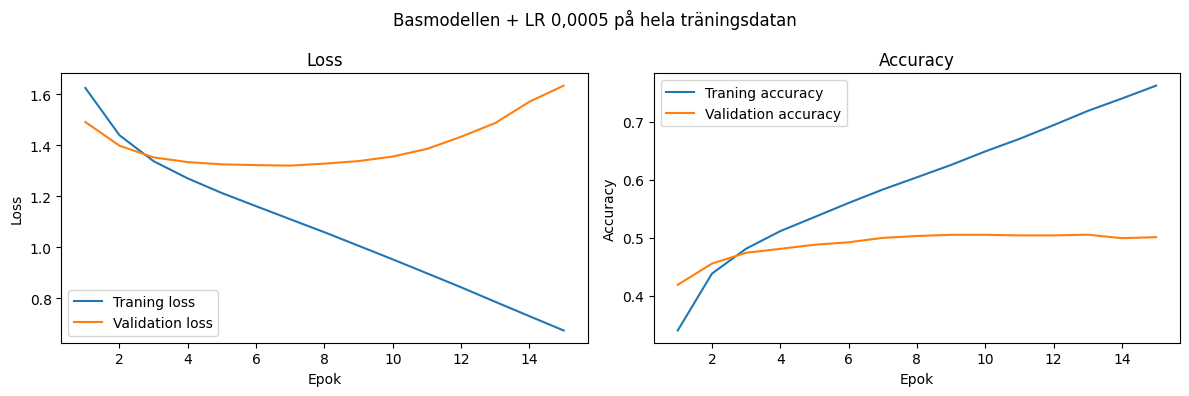

                                         name  train_accuracy  train_loss  val_accuracy  val_loss  best_epoch  training_time
                                    Basmodell        0.723750    0.794418      0.393333  1.914599          12      22.387358
                                  Dropout 0.2        0.778750    0.618427      0.375000  2.091327          15      22.640146
                                  Dropout 0.4        0.599167    1.046693      0.381667  1.698354          14      22.519528
                                  Dropout 0.5        0.602500    1.058368      0.370000  1.702722          14      22.411260
                                      L2 0.01        0.326250    1.705103      0.305000  1.740972          15      24.838328
                                     L2 0.001        0.617083    1.152550      0.393333  1.872329          15      24.034297
                                    L2 0.0001        0.576667    1.172518      0.383333  1.697725           9      24.002508


In [19]:
# Bygger och tränar en modell med alla träningsbilder (utan disgust)
X_train = X_train_full
X_val = X_val_full
y_train = y_train_full
y_val = y_val_full

model_bas_full, h_bas_full, r_bas_full = run_experiment(
    "Basmodellen + LR 0,0005 på hela träningsdatan",
    learning_rate=0.0005,
)

results.append(r_bas_full)
print(pd.DataFrame(results).to_string(index=False))

In [20]:
# Jämför resultat mellan modellen på subsetet och modellen på hela träningsdatan
compare_subset_vs_full(
    "Basmodellen + LR 0,0005 med subset", r_bas,
    "Basmodellen + LR 0,0005 med hela träningsdatan", r_bas_full
)

,Modell,Training Accuracy,Training Loss,Validation Accuracy,Validation Loss
0,"Basmodellen + LR 0,0005 med subset",0.723750,0.794418,39.3%,1.9146
1,"Basmodellen + LR 0,0005 med hela träningsdatan",0.718277,0.786314,50.5%,1.4866


#### Kommentar

Med hela träningsdatan förbättras accuracy på valideringsdatan från 39,3% till 50,5% vilket är en markant förböttring jämfört med tidigare experiment som visar att mer data hjälper modellen att generalisera bättre. Kurvorna visar att modellen fortfarande överanpassar men accuracy på valideringsdatan planar ut på en högre nivå än med subsetet. Detta tyder på att datamängd är en viktig faktor för denna typ av problem.


Experiment: Större modellen på hela träningsdatan
Antal epoker:   15
Training accuracy:      0.7604
Training loss:          0.6742
Validation accuracy: 0.4935
Validation loss:     1.6610
Träningstid:    614.66 sekunder


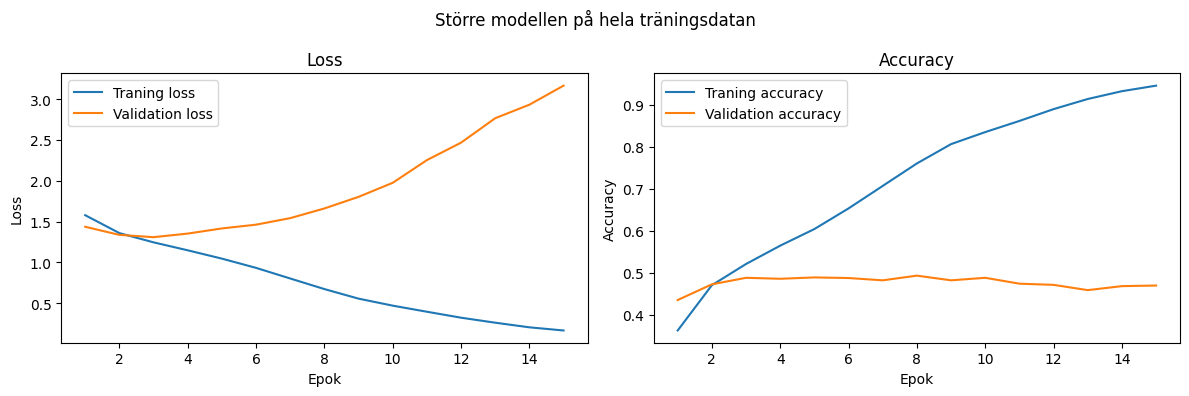

                                         name  train_accuracy  train_loss  val_accuracy  val_loss  best_epoch  training_time
                                    Basmodell        0.723750    0.794418      0.393333  1.914599          12      22.387358
                                  Dropout 0.2        0.778750    0.618427      0.375000  2.091327          15      22.640146
                                  Dropout 0.4        0.599167    1.046693      0.381667  1.698354          14      22.519528
                                  Dropout 0.5        0.602500    1.058368      0.370000  1.702722          14      22.411260
                                      L2 0.01        0.326250    1.705103      0.305000  1.740972          15      24.838328
                                     L2 0.001        0.617083    1.152550      0.393333  1.872329          15      24.034297
                                    L2 0.0001        0.576667    1.172518      0.383333  1.697725           9      24.002508


In [ ]:
# Bygger och tränar en bredare modell med alla träningsbilder (utan disgust)
model_big_full, h_big_full, r_big_full = run_experiment(
    "Bredare modellen på hela träningsdatan",
    num_filters_1=64,
    num_filters_2=128,
    dense_units=256,
)

results.append(r_big_full)
print(pd.DataFrame(results).to_string(index=False))

In [ ]:
# Jämför resultat mellan den bredare modellen på subsetet och den bredare modellen på hela träningsdatan
compare_subset_vs_full(
    "Bredare modellen med subset", r_big,
    "Bredare modellen med hela träningsdatan", r_big_full
)

,Modell,Training Accuracy,Training Loss,Validation Accuracy,Validation Loss
0,Större modellen med subset,0.740000,0.739308,39.2%,2.1762
1,Större modellen med hela träningsdatan,0.760412,0.674187,49.4%,1.6610


#### Kommentar

Den bredare modellen på hela träningsdatan förbättras från 39,2% till 49,4% jämfört med subsetet, vilket igen visar att mer data hjälper. Den har däremot ett något sämre accuracy på valideringsdatan än basmodellen med LR 0,0005 trots sina dubblerade filter och noder. Kurvorna visar tidig överanpassning vilket tyder på att modellen snarare blir bättre på träningsdatan än på att generalisera i jämförelse med basmodellen och LR 0,0005.


Experiment: Basmodellen + LR 0,0005 + extra Conv2D-lager på hela träningsdatan
Antal epoker:   15
Training accuracy:      0.6709
Training loss:          0.8898
Validation accuracy: 0.5482
Validation loss:     1.2234
Träningstid:    260.39 sekunder


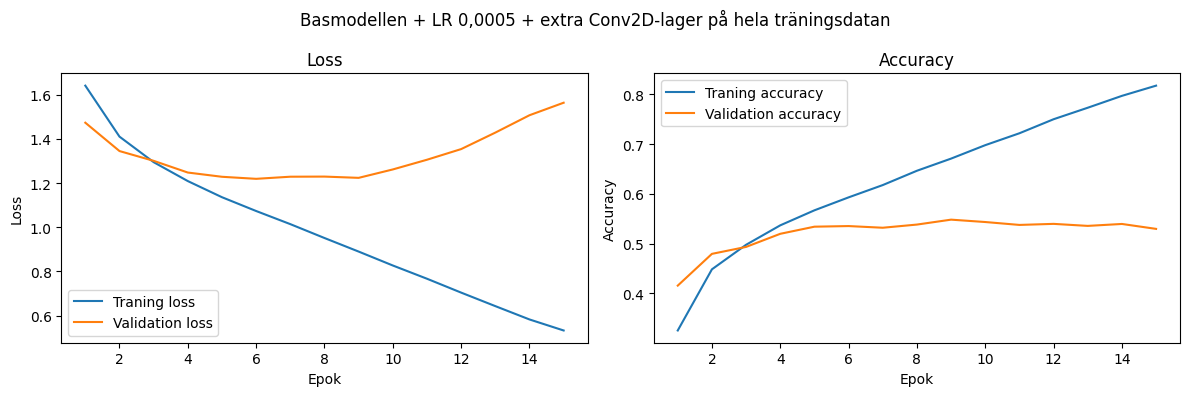

                                                              name  train_accuracy  train_loss  val_accuracy  val_loss  best_epoch  training_time
                                                         Basmodell        0.723750    0.794418      0.393333  1.914599          12      22.387358
                                                       Dropout 0.2        0.778750    0.618427      0.375000  2.091327          15      22.640146
                                                       Dropout 0.4        0.599167    1.046693      0.381667  1.698354          14      22.519528
                                                       Dropout 0.5        0.602500    1.058368      0.370000  1.702722          14      22.411260
                                                           L2 0.01        0.326250    1.705103      0.305000  1.740972          15      24.838328
                                                          L2 0.001        0.617083    1.152550      0.393333  1.872329      

In [23]:
# Bygger och tränar en modell med alla träningsbilder (utan disgust) och ett tredje Conv2D-lager
model_bas_3layers_full, h_bas_3layers_full, r_bas_3layers_full = run_experiment(
    "Basmodellen + LR 0,0005 + extra Conv2D-lager på hela träningsdatan",
    learning_rate=0.0005,
    num_filters_3=128
)

results.append(r_bas_3layers_full)
print(pd.DataFrame(results).to_string(index=False))

In [24]:
# Skapar en DataFrame för att på tydligt vis presentera resultatet från samtliga experiment
display(pd.DataFrame(results)
    .sort_values("val_accuracy", ascending=False)
    .style.format({
    "train_accuracy": "{:.4f}",
    "train_loss": "{:.4f}",
    "val_accuracy": "{:.4f}",
    "val_loss": "{:.4f}",
    "best_epoch": "{:.0f}",
    "training_time": "{:.1f}s"
}).highlight_max(subset=["val_accuracy"], color="darkgreen")
  .highlight_min(subset=["val_loss"], color="darkblue")
  .set_caption("Sammanfattning av alla experiment")
  .set_table_styles([{"selector": "caption", "props": [("font-size", "16px"), ("font-weight", "bold")]}]))

,name,train_accuracy,train_loss,val_accuracy,val_loss,best_epoch,training_time
13,"Basmodellen + LR 0,0005 + extra Conv2D-lager på hela träningsdatan",0.6709,0.8898,0.5482,1.2234,9,260.4s
11,"Basmodellen + LR 0,0005 på hela träningsdatan",0.7183,0.7863,0.5050,1.4866,13,188.1s
12,Större modellen på hela träningsdatan,0.7604,0.6742,0.4935,1.6610,8,614.7s
8,LR 0.0005,0.6750,0.9397,0.4067,1.7011,14,24.1s
0,Basmodell,0.7237,0.7944,0.3933,1.9146,12,22.4s
5,L2 0.001,0.6171,1.1525,0.3933,1.8723,15,24.0s
10,Större modell,0.7400,0.7393,0.3917,2.1762,11,60.4s
6,L2 0.0001,0.5767,1.1725,0.3833,1.6977,9,24.0s
2,Dropout 0.4,0.5992,1.0467,0.3817,1.6984,14,22.5s
1,Dropout 0.2,0.7788,0.6184,0.3750,2.0913,15,22.6s


#### Sammanfattning experiment med hela träningsdatan

Resultaten visar att mer data är den viktigaste faktorn för förbättring då alla modeller presterade bättre på hela träningsdatan än på subsettet. Den djupare modellen med ett extra Conv2D-lager gav bäst val_accuracy (54,8%), vilket tyder på att ökad djup gynnas av mer data medan ökad bredd inte hjälpte lika mycket. Detta kan bero på att fler Conv2D-lager bygger upp en mer och mer avancerad mönsterförståelse medan fler filter lär sig fler varianter av mönster på samma nivå.

In [25]:
# Sparar den bästa modellen (basmodellen med extra Conv2D-lager tränad på hela datan) i Keras-format
final_model = model_bas_3layers_full
final_model.save("final_model.keras")

### Felanalys på valideringsdatan

För att förstå var modellen misslyckas analyseras prediktionerna på valideringsdatan. Konfusionsmatrisen visar hur många bilder som klassificerats rätt respektive fel per klass, och per-klass accuracy identifierar vilka känslor som är svårast att känna igen. Slutligen visas exempel på felklassificerade bilder tillsammans med modellens säkerhet.

#### Funktion för prediktion och sannolikhet

In [26]:
def predict_classes(model, X):

    """
    Returnerar predikterade klasser och sannolikheter för en modell.
    """
    
    y_proba = model.predict(X, verbose=0)
    y_pred = np.argmax(y_proba, axis=1)

    return y_pred, y_proba

In [27]:
# Predikterar klasser och sannolikheter på valideringsdatan
final_model_val_pred, final_model_val_proba = predict_classes(final_model, X_val)

#### Funktion för att plotta konfusionsmatris

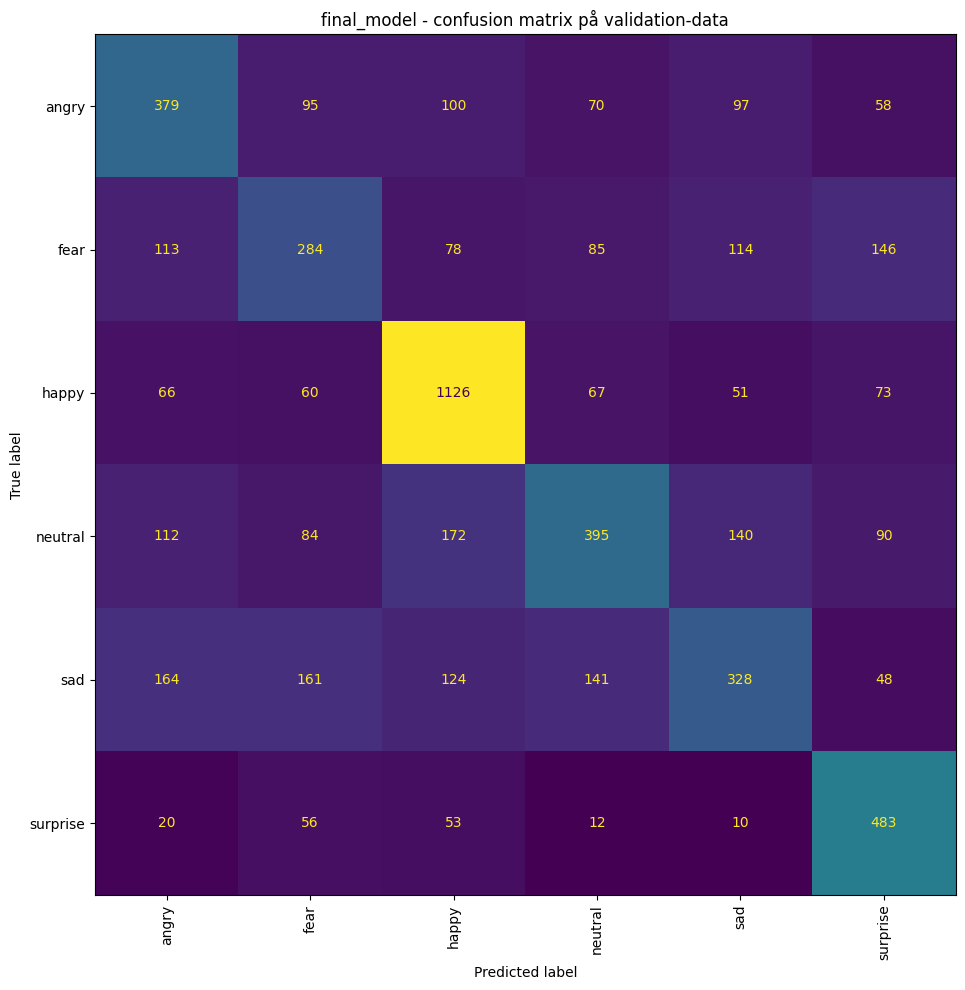

In [28]:
def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion matrix"):

    """
    Plottar en konfusionsmatris och returnerar den som numpy-array.
    """

    labels = np.arange(len(class_names))

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels
    )

    fig, ax = plt.subplots(figsize=(12, 10))

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    display.plot(
        ax=ax,
        xticks_rotation=90,
        values_format="d",
        colorbar=False
    )

    plt.title(title)
    plt.tight_layout()
    plt.show()

    return cm

# Konfusionsmatris på valideringsdatan
final_model_cm = plot_confusion_matrix(
    y_val,
    final_model_val_pred,
    class_names_filtered,
    title="final_model - confusion matrix på validation-data")

#### Kommentar

Happy och surprise har tydliga diagonalvärden vilket indikerar att modellen känner igen dessa klasser bra. Sad och fear sprids ut över flera klasser och är svårast att klassificera korrekt.

#### Funktion för att beräkna accuracy för respektive klass

In [29]:
def calculate_per_class_accuracy(cm, class_names):

    """
    Beräknar accuracy per klass från en konfusionsmatris.
    Returnerar en DataFrame sorterad efter accuracy (lägst först).
    """

    support = cm.sum(axis=1)
    correct = np.diag(cm)

    accuracy = correct / support

    result = pd.DataFrame({
        "class_id": np.arange(len(class_names)),
        "class_name": class_names,
        "support": support,
        "correct": correct,
        "accuracy": accuracy
    })

    return result.sort_values("accuracy")


final_model_per_class = calculate_per_class_accuracy(
    final_model_cm,
    class_names_filtered
)

print("Per-klass accuracy på valideringsdata")

# Per-klass accuracy sorterad från sämst till bäst
final_model_per_class.style\
    .format({"accuracy": "{:.1%}"})\
    .background_gradient(subset=["accuracy"], cmap="RdYlGn")

Per-klass accuracy på valideringsdata


,class_id,class_name,support,correct,accuracy
4,4,sad,966,328,34.0%
1,1,fear,820,284,34.6%
3,3,neutral,993,395,39.8%
0,0,angry,799,379,47.4%
5,5,surprise,634,483,76.2%
2,2,happy,1443,1126,78.0%


#### Kommentar

Happy, 78% och surprise, 76% är lättast medan sad, 34% och fear, 35% är svårast. Skillnaden på 44 procentenheter mellan bästa och sämsta klass är stor.

#### Funktion för att visa de vanligaste felklassificeringarna

In [30]:
def get_most_confused_pairs(cm, class_names, top_n=10):

    """
    Returnerar de vanligaste felklassificeringarna som en DataFrame.
    Sorterad efter antal fel, högst först.
    """

    pairs = []

    for true_class in range(cm.shape[0]):
        for predicted_class in range(cm.shape[1]):
            if true_class == predicted_class:
                continue

            count = cm[true_class, predicted_class]

            if count > 0:
                pairs.append({
                    "true_class_id": true_class,
                    "true_class": class_names[true_class],
                    "predicted_class_id": predicted_class,
                    "predicted_class": class_names[predicted_class],
                    "count": count
                })

    pairs_df = pd.DataFrame(pairs)

    if pairs_df.empty:
        return pairs_df

    return pairs_df.sort_values("count", ascending=False).head(top_n)

final_model_confusions = get_most_confused_pairs(
    final_model_cm,
    class_names_filtered
)

print("Mest felklassificerade par på valideringsdata")

# De 10 vanligaste felklassificeringarna
final_model_confusions.style\
    .background_gradient(subset=["count"], cmap="RdYlGn_r")


Mest felklassificerade par på valideringsdata


,true_class_id,true_class,predicted_class_id,predicted_class,count
17,3,neutral,2,happy,172
20,4,sad,0,angry,164
21,4,sad,1,fear,161
9,1,fear,5,surprise,146
23,4,sad,3,neutral,141
18,3,neutral,4,sad,140
22,4,sad,2,happy,124
8,1,fear,4,sad,114
5,1,fear,0,angry,113
15,3,neutral,0,angry,112


#### Kommentar

Neutral förväxlas ofta med happy, och sad förväxlas med angry och fear.

#### Funktion för att skriva ut felklassificerade bilder

Antal felklassificerade exempel: 2660


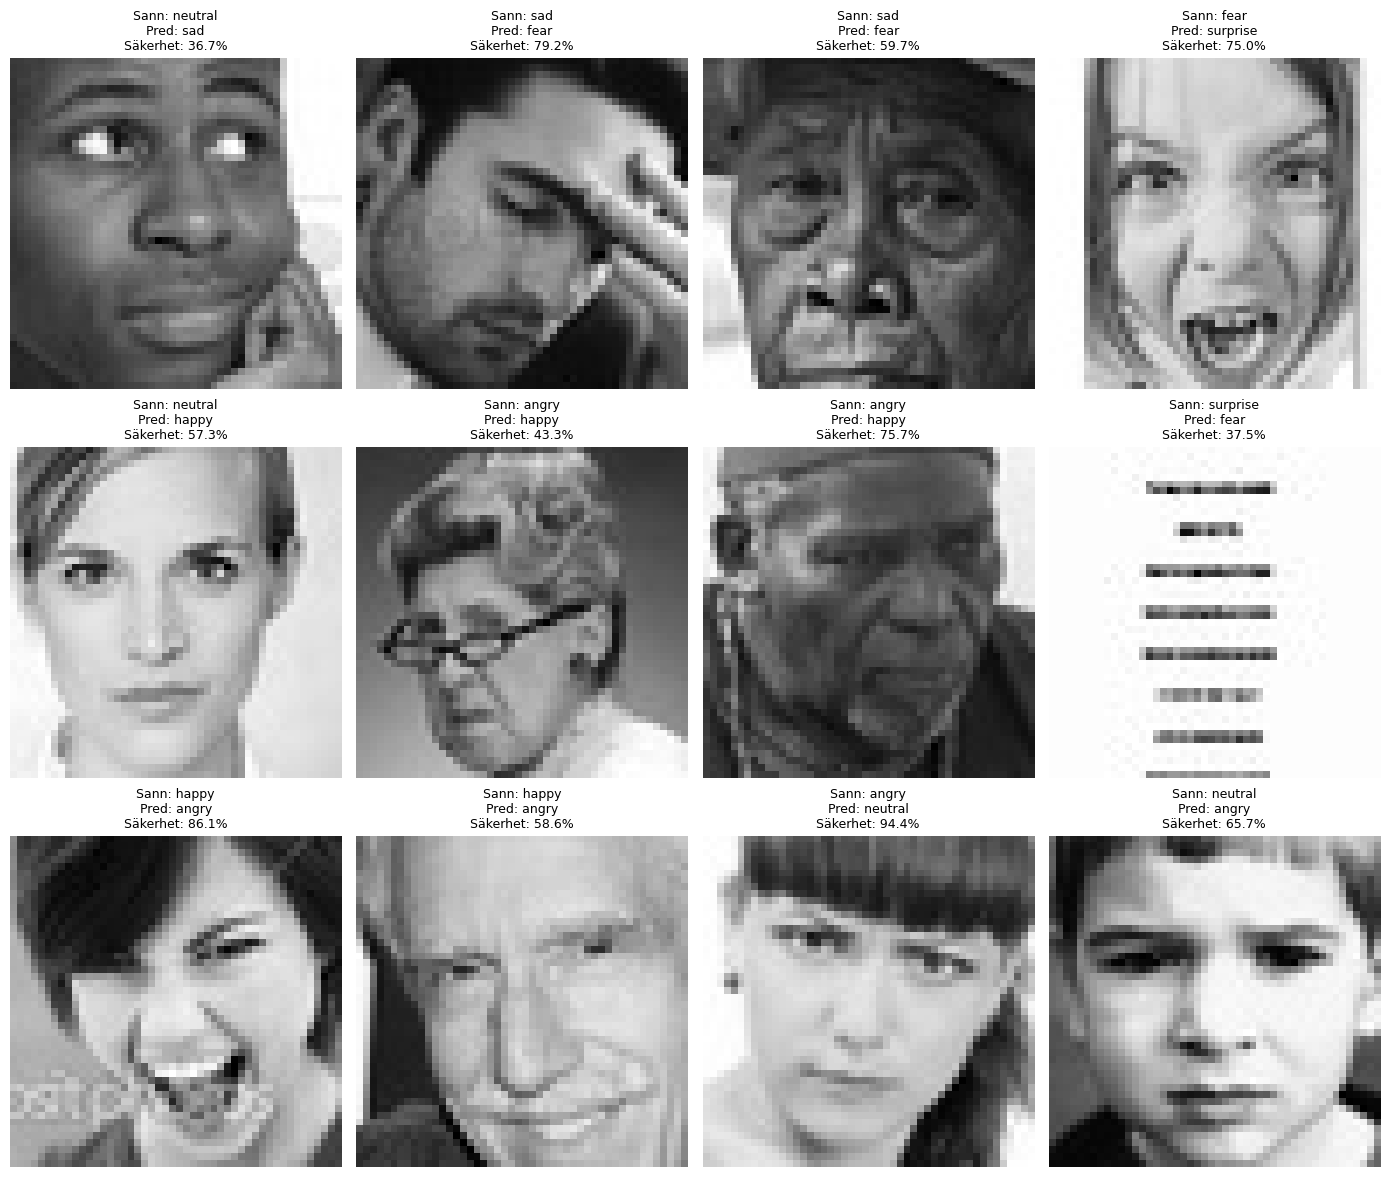

In [31]:
def plot_misclassified_examples(
    X,
    y_true,
    y_pred,
    y_proba,
    class_names,
    n_images=12,
    random_state=42
):
    
    """
    Visar slumpmässigt utvalda felklassificerade bilder med sann klass,
    predikterad klass och modellens säkerhet.
    """

    error_indices = np.where(y_true != y_pred)[0]

    print(f"Antal felklassificerade exempel: {len(error_indices)}")

    if len(error_indices) == 0:
        print("Inga felklassificerade exempel att visa.")
        return

    rng = np.random.default_rng(random_state)

    chosen_indices = rng.choice(
        error_indices,
        size=min(n_images, len(error_indices)),
        replace=False
    )

    cols = 4
    rows = int(np.ceil(len(chosen_indices) / cols))

    plt.figure(figsize=(14, 4 * rows))

    for plot_index, data_index in enumerate(chosen_indices):
        true_label = y_true[data_index]
        pred_label = y_pred[data_index]
        confidence = y_proba[data_index, pred_label] * 100

        plt.subplot(rows, cols, plot_index + 1)
        plt.imshow(X[data_index].squeeze(), cmap="gray")
        plt.title(
            f"Sann: {class_names[true_label]}\n"
            f"Pred: {class_names[pred_label]}\n"
            f"Säkerhet: {confidence:.1f}%",
            fontsize=9
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Visar 12 slumpmässiga felklassificeringar med sann klass och modellens säkerhet
plot_misclassified_examples(
    X_val,
    y_val,
    final_model_val_pred,
    final_model_val_proba,
    class_names_filtered,
    n_images=12,
    random_state=42
)

#### Kommentar

Flera av de felklassificerade bilderna är svåra att tolka även för en människa, som bilder med händer framför ansiktet, bilder från sidan eller otydliga uttryck. 
En bild verkar också vara censurerad vilket bidrar till felet.

#### Sammanfattning felanalys på valideringsdata

Modellen presterar bäst på känslouttryck som happy och surprise men kämpar med uttryck som sad och fear. En del fel kan förklaras av bildkvalitet och ovanliga vinklar snarare än modellens begränsningar.

## 5. Utvärdera modellen

Den slutliga modellen utvärderas på testdatan som inte använts under träning eller experimentfasen. Testdatan ger ett objektivt mått på hur väl modellen generaliserar till ny data. Resultaten jämförs med valideringsdatan för att kontrollera att modellen inte är överanpassad till valideringsdatan.

In [32]:
# Laddar sparad modell och utvärderar på testdata
final_model = keras.models.load_model("final_model.keras")

test_loss, test_accuracy = final_model.evaluate(X_test_filtered, y_test_filtered, verbose=0)

# Jämför resultat på validerings- och testdata
comparison_overall = pd.DataFrame([
    {"dataset": "Validering", "accuracy": r_bas_3layers_full["val_accuracy"], "loss": r_bas_3layers_full["val_loss"]},
    {"dataset": "Test", "accuracy": test_accuracy, "loss": test_loss}
])

comparison_overall.style\
    .format({"accuracy": "{:.1%}", "loss": "{:.4f}"})\
    .background_gradient(subset=["accuracy"], cmap="RdYlGn")

,dataset,accuracy,loss
0,Validering,54.8%,1.2234
1,Test,52.8%,1.5810


### Prediktion, sannolikhet och felanalys på testdata

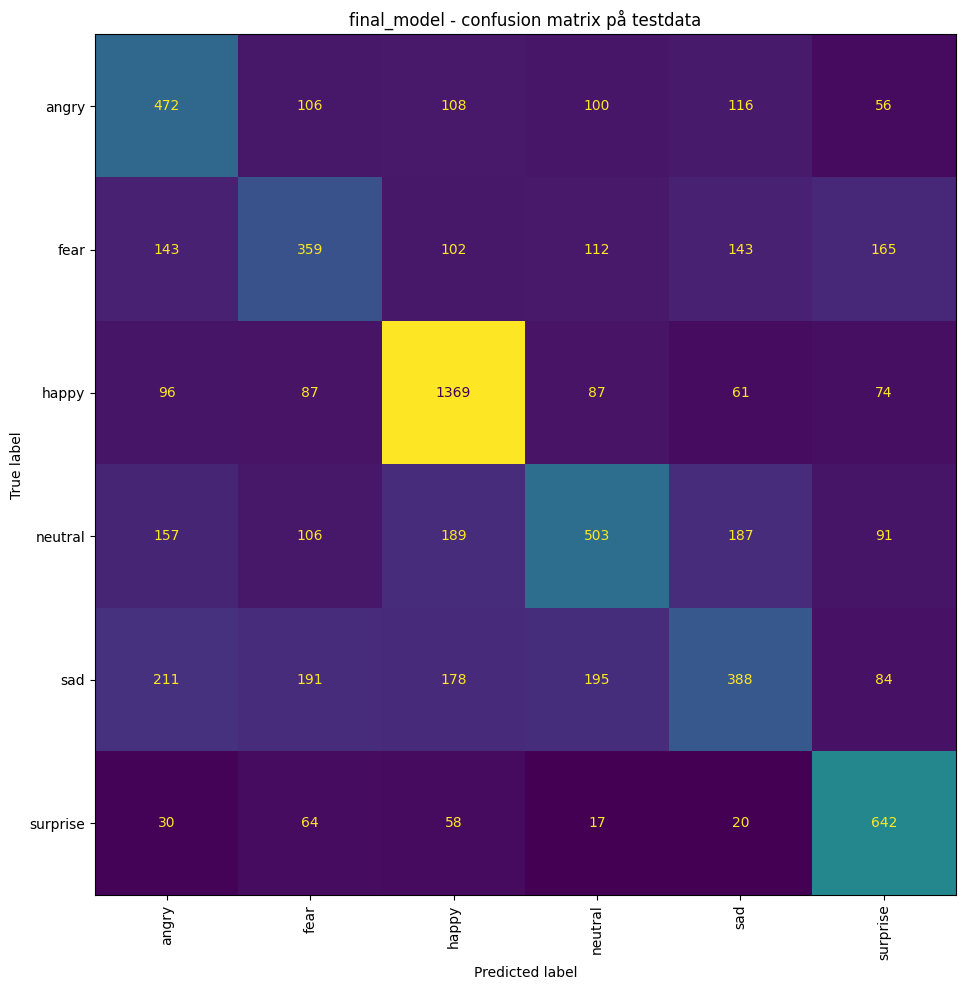

In [ ]:
# Predikterar på testdata
test_pred, test_proba = predict_classes(final_model, X_test_filtered)

# Konfusionsmatris på testdata
final_model_test_cm = plot_confusion_matrix(
    y_test_filtered,
    test_pred,
    class_names_filtered,
    title="final_model - confusion matrix på testdata"
)

# Per-klass accuracy på testdata
final_model_test_per_class = calculate_per_class_accuracy(
    final_model_test_cm,
    class_names_filtered
)

#### Kommentar

Mönstret liknar valideringsdatan – happy och surprise har starka diagonalvärden medan sad och fear sprids ut över flera klasser. Angry presterar något bättre på testdatan, 472 rätt jämfört med valideringsdatan.

In [42]:
# Jämför per-klass accuracy mellan validerings- och testdata
comparison = final_model_per_class[["class_name", "accuracy"]].merge(
    final_model_test_per_class[["class_name", "accuracy"]],
    on="class_name",
    suffixes=("_val", "_test")
)

comparison.sort_values("accuracy_test").style\
    .format({"accuracy_val": "{:.1%}", "accuracy_test": "{:.1%}"})\
    .background_gradient(subset=["accuracy_val", "accuracy_test"], cmap="RdYlGn")

,class_name,accuracy_val,accuracy_test
0,sad,34.0%,31.1%
1,fear,34.6%,35.1%
2,neutral,39.8%,40.8%
3,angry,47.4%,49.3%
5,happy,78.0%,77.2%
4,surprise,76.2%,77.3%


#### Kommentar

Resultaten är konsekventa mellan validering och test, samma klasser är svårast och lättast. Angry förbättras från 47,4% till 49,3% medan sad försämras något, 34,0% till 31,1% på testdatan medan övriga klasser är mycket lika, vilket tyder på att modellen generaliserar stabilt.

Antal felklassificerade exempel: 3334


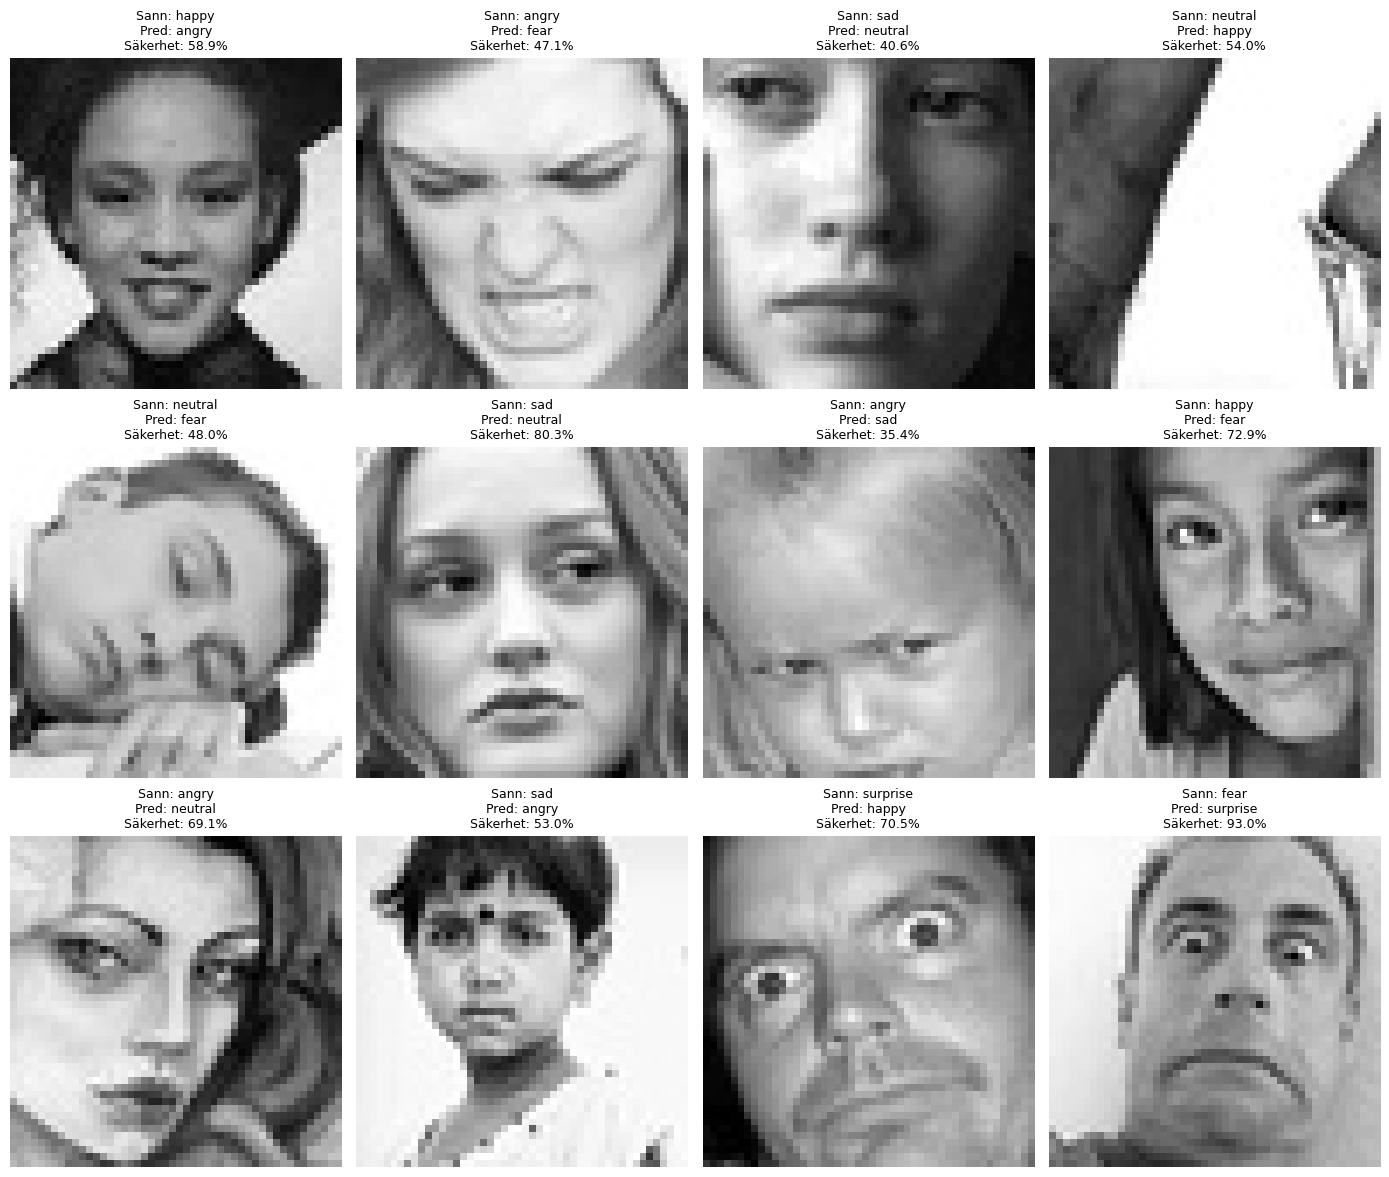

In [35]:
# Visar 12 slumpmässiga felklassificeringar från testdata med sann klass och modellens säkerhet
plot_misclassified_examples(
    X_test_filtered,
    y_test_filtered,
    test_pred,
    test_proba,
    class_names_filtered,
    n_images=12,
    random_state=42
)

#### Kommentar

Flera av de felklassificerade bilderna är svåra att tolka även för en människa, bilder tagna från sidan, med händer framför ansiktet, med tvetydiga uttryck eller tveksamt om det ens är ett ansikte.  
Detta speglar utmaningen med FER-2013 där bildkvalitet och subjektiva labels påverkar resultatet.

#### Sammanfattning felanalys på testdata

Felanalysen på testdatan bekräftar bilden från valideringsdatan. Modellen är konsekvent i sina styrkor och svagheter, vilket tyder på god generalisering snarare än överanpassning till valideringsdatan.

## 6. Gör prediktioner på ny data

För att visa att modellen fungerar som ett program används den för att klassificera en enskild bild från testdatan. Bilden förbereds på samma sätt som träningsdatan och modellen returnerar en sannolikhet för varje känslouttryck. Den klass med högst sannolikhet är modellens prediktion.

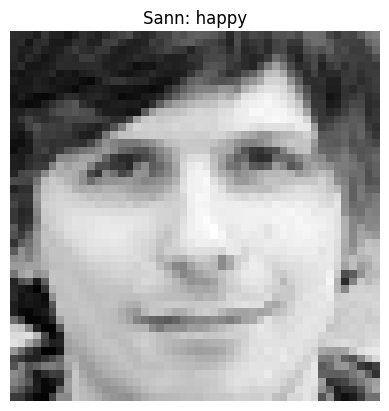

Sann label: happy
Predikterad label: happy


,Klass,Sannolikhet %
2,happy,92.3
3,neutral,7.7
0,angry,0.0
5,surprise,0.0
1,fear,0.0
4,sad,0.0


In [36]:
# Prediktion på en enskild bild från testdatan (index 2001)
# Visar bilden, sann klass, predikterad klass och sannolikhet per klass
image_index = 2001

probabilities = pd.DataFrame({
    "Klass": class_names_filtered,
    "Sannolikhet": test_proba[image_index]
})

probabilities = probabilities.sort_values(
    by="Sannolikhet",
    ascending=False
)

probabilities["Sannolikhet %"] = (probabilities["Sannolikhet"] * 100).round(2)

plt.imshow(X_test_filtered[image_index].squeeze(), cmap="gray")
plt.axis("off")
plt.title(f"Sann: {class_names_filtered[y_test_filtered[image_index]]}")
plt.show()

print("Sann label:", class_names_filtered[y_test_filtered[image_index]])
print("Predikterad label:", class_names_filtered[test_pred[image_index]])
probabilities[["Klass", "Sannolikhet %"]].style\
    .format({"Sannolikhet %": "{:.1f}"})\
    .background_gradient(subset=["Sannolikhet %"], cmap="RdYlGn")

### Kommentar

Modellen klassificerade bilden korrekt som happy med 92,3% säkerhet.

### Funktion för att prediktera nya bilder

In [37]:
# Prediktion på egna bilder
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def predict_multiple_images(model, class_names, image_paths):
    """
    Visar flera egna bilder bredvid varandra med predikterad klass.
    """
    n = len(image_paths)
    plt.figure(figsize=(4 * n, 4))
    
    for i, path in enumerate(image_paths):
        img = load_img(path, color_mode="grayscale", target_size=(48, 48))
        img_array = img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        
        pred_label, pred_proba = predict_classes(model, img_array)
        confidence = pred_proba[0].max() * 100
        
        plt.subplot(1, n, i + 1)
        plt.imshow(img_array.squeeze(), cmap="gray")
        plt.title(f"Pred: {class_names[pred_label[0]]}\n{confidence:.1f}%", fontsize=9)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

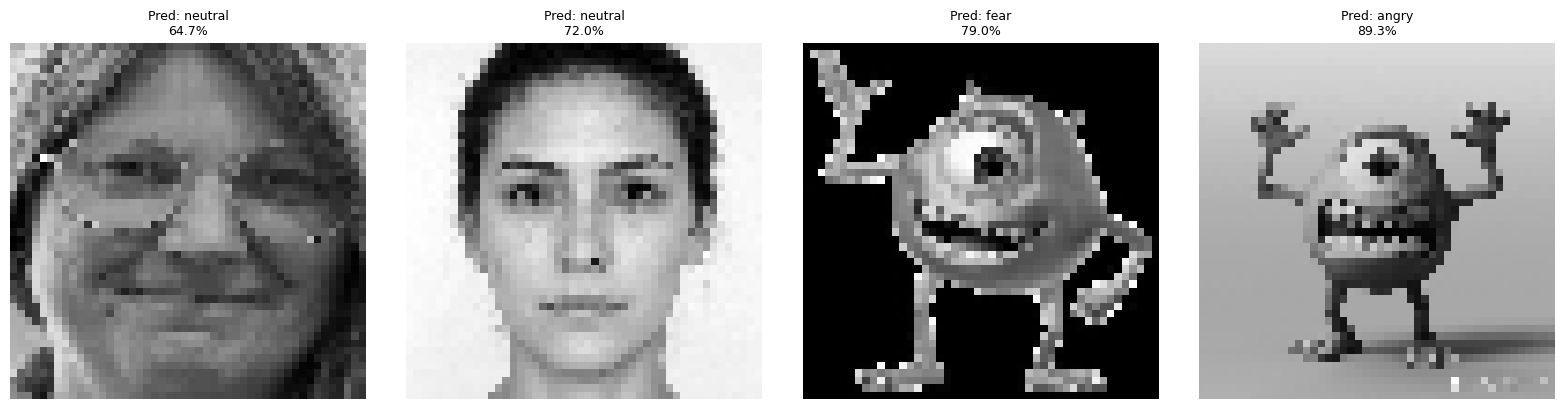

In [38]:
predict_multiple_images(final_model, class_names_filtered, [
    "data/egen_testbild.jpg",
    "data/ai_testbild.jpg",
    "data/mike_wazowski_happy.jpg",
    "data/mike_wazowski_angry.jpg"
])

### Kommentar

Modellen klassificerade den egna bilden som neutral trots ett leende, vilket kan beror på att glasögon stör igenkänningen. Den AI-genererade bilden klassificerades också som neutral, vilket får anses rätt. Mike Wazowski klassificerades som fear och angry, vilket kanske inte är orimligt givet hans stora ögon och tandade leende, men illustrerar att modellen inte fungerar på icke-mänskliga ansikten.

## 7. Analysera resultatet
 
**Hur bra fungerar modellen?**  
Den modell som valdes som bäst vad basmodellen med LR 0,0005 och ett extra (tredje) Conv2D-lager. Modellen fick 54,8% accuracy på valideringsdatan och 52,8% på testdatan vilket visar att modellen generaliserar bra och inte har överanpassat till valideringsdatan. Dock är en accuracy på strax över 50% inte mycket bättre än att kasta mynt men för 6 klasser så är slumpen 16,7%. Ansiktsutryck är svårt att klassificera så det är inte så överraskande och datasetet innehåller bilder med händer framför ansiktet, bilder från sidan eller otydliga uttryck och ibland tveksamt om det ens är ansikten på bilderna.

52,8% är accuracy på alla klasser tillsammans och det är därför intressant att titta på accuracy för varje klass för sig. Här ser man en stor skillnad där happy och surprise som har accuracy på runt 77% jämfört med sad 31% och fear 35%. Modellen presterar bäst på känslouttryck som happy och surprise men kämpar med uttryck som sad och fear. 

Utskrift av felklassificerade bilder ger en inblick i svårigheten med datasetet. En del fel kan förklaras av bildkvalitet och ovanliga vinklar snarare än modellens begränsningar.

**Ser du tecken på overfitting eller underfitting?**  
Modellen överanpassade i alla experiment och regularisering eller en bredare mer komplex modellvariant hade ingen större effekt på detta utan att också försämra accuracy på valideringsdatan (t.ex. basmodellen med LR 0,01) när experiment kördes på subsetet. Med mer data så minskade gapet mellan accuracy på träningsdatan och valideringsdatan då den senare ökade.

**Hur skiljer sig modellens resultat mellan träningsdata och testdata?**  
Resultat och fel var ganska lika mellan valideringsdatan med total accuracy på 54,8% och testdatan med total accuracy på 52,8%. Modellen hade något sämre accuracy på testdatan för klassen sad, 31%  jämfört med valideringsdatans 34% men var något bättre på klassen angry med 49% mot valideringsdatans 47%. Skillnaden i övriga klasse var mindre än så. Detta tyder på att modellen generaliserar bra på testdatan.

**Vad verkar påverka resultatet mest?** 
De genomförda experimenten tyder på att mängden träningsdata och en djupare arkitektur (fler Conv2D-lager) hade störst effekt. Dropout, L2-regularisering och olika learning rates gav mindre förbättringar, där LR 0.0005 visade sig fungera något bättre än standardvärdet 0.001.

**Vilka begränsningar har din modell?**  
Datasetet är utmanande både vad gäller bildkvalitet och eventuellt subjektiva labels. Modellen har också en relativt enkel arkitektur och skulle kunnat göras djupare.

Deep learning lämpar sig bäst när det finns stora mängder märkt data och tillräcklig beräkningskraft. För ansiktsigenkänning är det ett rimligt val 
då mönstren i bilddata är komplexa, men med ett relativt litet dataset som FER-2013 kan enklare metoder eller transfer learning från förtränade modeller ge bättre resultat.

## 8. Reflektion
  
**Vad var svårast i uppgiften?**
Det känns svårt när modellen överanpassar mycket och inga experiment för att reducera det ger någon större effekt. Jag tycker även det var svårt med ett dataset där man själv ifrågasätter om det är rätt labels.  

**Vad lärde du dig?**
Att datamängd ofta spelar större roll än modellkomplexitet, och att ansiktsuttryck är ett genuint svårt problem men där även enkla CNN når rimliga resultat.

**Vad hade du gjort annorlunda om du började om?** 
Med det jag lärt mig från de experiment jag gjort så skulle jag köra på hela datasetet från början och se om regularisering hade reducerat överanpassningen. Claude föreslog att använda ResNet50 och transfer learning och det kanske jag testar på egen hand. 

**Vilket betyg tycker du att din inlämning motsvarar, G eller VG?**   
VG. Jag har jämfört flera modellvarianter (basmodell, bredare modell och djupare modell) och systematiskt testat hyperparametrar (dropout, L2, learning rate). Resultaten analyseras med konfusionsmatris och per-klass accuracy, och jag för en kritisk diskussion om modellens begränsningar och när deep learning är lämpligt. 